# Lecture 2 — Data-Driven Investment Decision Making

### The claim on trial

> **"Better features make better decisions."**

This is the premise of the entire quantitative investment industry, and of most of what
you will read about machine learning in finance. Today we put it on trial.

We will build a perfectly reasonable stock-selection strategy, measure it, and get a
result that would make you a very rich person. Then we will find out why it is a lie —
not because the model is wrong, but because the *data* is. By the end of the notebook the
strategy's Sharpe ratio will have fallen from **4.3 to 0.9**, and the entire drop will
come from fixing the data rather than changing a single line of the strategy.

### What you will be able to do afterwards

1. Recognise **look-ahead bias**, **survivorship bias** and **backfill bias** in a dataset,
   and explain why each one inflates measured performance.
2. Quantify how much of a backtest's apparent skill is a data artefact.
3. Build cross-sectional features from raw prices (momentum, volatility, liquidity) and
   normalise them so they are comparable across stocks.
4. Measure whether a feature actually predicts anything, using the **Information
   Coefficient**, and see how quickly that predictive power decays.

### How to use this notebook

It is written in two layers.

- **The main text** is the narrative: the finance, the intuition and the charts. You can
  follow the whole argument at this level without reading a line of maths.
- **Collapsed grey boxes** like the one below contain the formal definitions. Click to
  open them if you want the mathematics; skip them if you do not.

<details>
<summary><b>Show me an example of a maths box</b></summary>

The **annualised Sharpe ratio** of a monthly return series $r_t$ is

$$\text{SR} = \frac{\bar{r}}{\sigma_r}\sqrt{12}, \qquad
\bar{r} = \frac{1}{T}\sum_{t=1}^{T} r_t, \qquad
\sigma_r = \sqrt{\frac{1}{T-1}\sum_{t=1}^{T}(r_t - \bar{r})^2}$$

The $\sqrt{12}$ scales a monthly ratio to annual units, and assumes returns are
independent across months. That assumption is doing a lot of quiet work — we will
come back to it in Lecture 5.

</details>

**Exercises** at the end are marked **Core** (everyone) and **Stretch** (if you are
comfortable with statistics).

---

## 0. Setup

Run this cell once. It works on Google Colab, on a local Anaconda install and on Binder. It checks your packages, installs anything missing, and downloads
the two datasets we need into a local `airm_data/` folder so that later cells do not need
an internet connection.

Both datasets are public files hosted on GitHub — no account, no API key, no rate limits.

In [23]:
# =====================================================================
#  AIRM Lecture 2 — bootstrap.  Run once.
# =====================================================================
import sys, subprocess, urllib.request
from pathlib import Path

# --- 1. packages -----------------------------------------------------
REQUIRED = ["pandas", "numpy", "plotly"]
missing = []
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Installing: {', '.join(missing)} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Done. If a later cell fails with ImportError, restart the kernel and re-run.")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# --- 2. environment --------------------------------------------------
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    pio.renderers.default = "colab"          # Colab needs to be told explicitly

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 20)

# A single house style, so every chart in the course looks the same.
AIRM_TEMPLATE = "plotly_white"
AIRM_COLOURS  = ["#1b4965", "#c1121f", "#5fa8d3", "#e09f3e", "#606c38", "#8e7dbe"]

# --- 3. data ---------------------------------------------------------
DATA_DIR = Path("airm_data")
DATA_DIR.mkdir(exist_ok=True)
FORCE_REDOWNLOAD = False

SOURCES = {
    "prices.csv":       "https://raw.githubusercontent.com/plotly/datasets/master/all_stocks_5yr.csv",
    "constituents.csv": "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv",
}

def fetch(filename: str) -> Path:
    """Download a dataset once, then read it from the local cache."""
    path = DATA_DIR / filename
    if path.exists() and not FORCE_REDOWNLOAD:
        return path
    print(f"Downloading {filename} ...", end=" ")
    urllib.request.urlretrieve(SOURCES[filename], path)
    print(f"{path.stat().st_size / 1e6:.1f} MB")
    return path

for name in SOURCES:
    fetch(name)

print(f"\nReady.  pandas {pd.__version__} | numpy {np.__version__} | Colab: {IN_COLAB}")


Ready.  pandas 2.3.2 | numpy 1.26.4 | Colab: False


---

## 1. The decision we are trying to make

Strip away the technology and almost every equity investment problem reduces to one
question, asked over and over:

> **Given everything I know today, which stocks should I hold next month?**

Note what this question is *not*. It is not "what will Apple's price be on 14 September".
Nobody in the industry is paid to answer that. The question is **cross-sectional** and
**relative**: out of the 500 stocks available to me, which ones will do better than the
others? You can be hopelessly wrong about the market's direction and still make money if
your ranking is good.

That reframing matters enormously for machine learning, because it changes the target
variable from a price (nearly unpredictable) to a *rank* (slightly predictable), and it
gives you 500 observations per month instead of one.

### Our data

Daily prices and volumes for the S&P 500, February 2013 to February 2018. Five years,
505 companies, 619,040 rows.

Hold on to a thought while you load it, though — a thought that is going to become the
whole point of this lecture:

> *Where did this list of 505 companies come from?*

In [24]:
# Load the raw price panel: one row per stock per day.
raw = pd.read_csv(fetch("prices.csv"), parse_dates=["date"])
raw = raw.rename(columns={"Name": "ticker"})

print(f"{len(raw):,} rows | {raw['ticker'].nunique()} tickers "
      f"| {raw['date'].min():%d %b %Y} to {raw['date'].max():%d %b %Y}")
raw.head()

619,040 rows | 505 tickers | 08 Feb 2013 to 07 Feb 2018


,date,open,high,low,close,volume,ticker
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [25]:
# Reshape to a price matrix: dates down the rows, tickers across the columns.
# This "wide" format is how you want price data for portfolio work, because a single
# pandas operation then applies to all 505 stocks at once.
prices = raw.pivot_table(index="date", columns="ticker", values="close")
volumes = raw.pivot_table(index="date", columns="ticker", values="volume")

print(f"prices matrix: {prices.shape[0]} days x {prices.shape[1]} stocks")
prices.iloc[:5, :6]

prices matrix: 1259 days x 505 stocks


ticker,A,AAL,AAP,AAPL,ABBV,ABC
date,,,,,,
2013-02-08,45.08,14.75,78.90,67.8542,36.25,46.89
2013-02-11,44.60,14.46,78.39,68.5614,35.85,46.76
2013-02-12,44.62,14.27,78.60,66.8428,35.42,46.96
2013-02-13,44.75,14.66,78.97,66.7156,35.27,46.64
2013-02-14,44.58,13.99,78.84,66.6556,36.57,46.77


### A first look

Before any modelling, look at the data. Always. The dropdown below switches between the
raw price level and the normalised version (every stock rebased to 100 at the start),
which is the only fair way to compare paths.

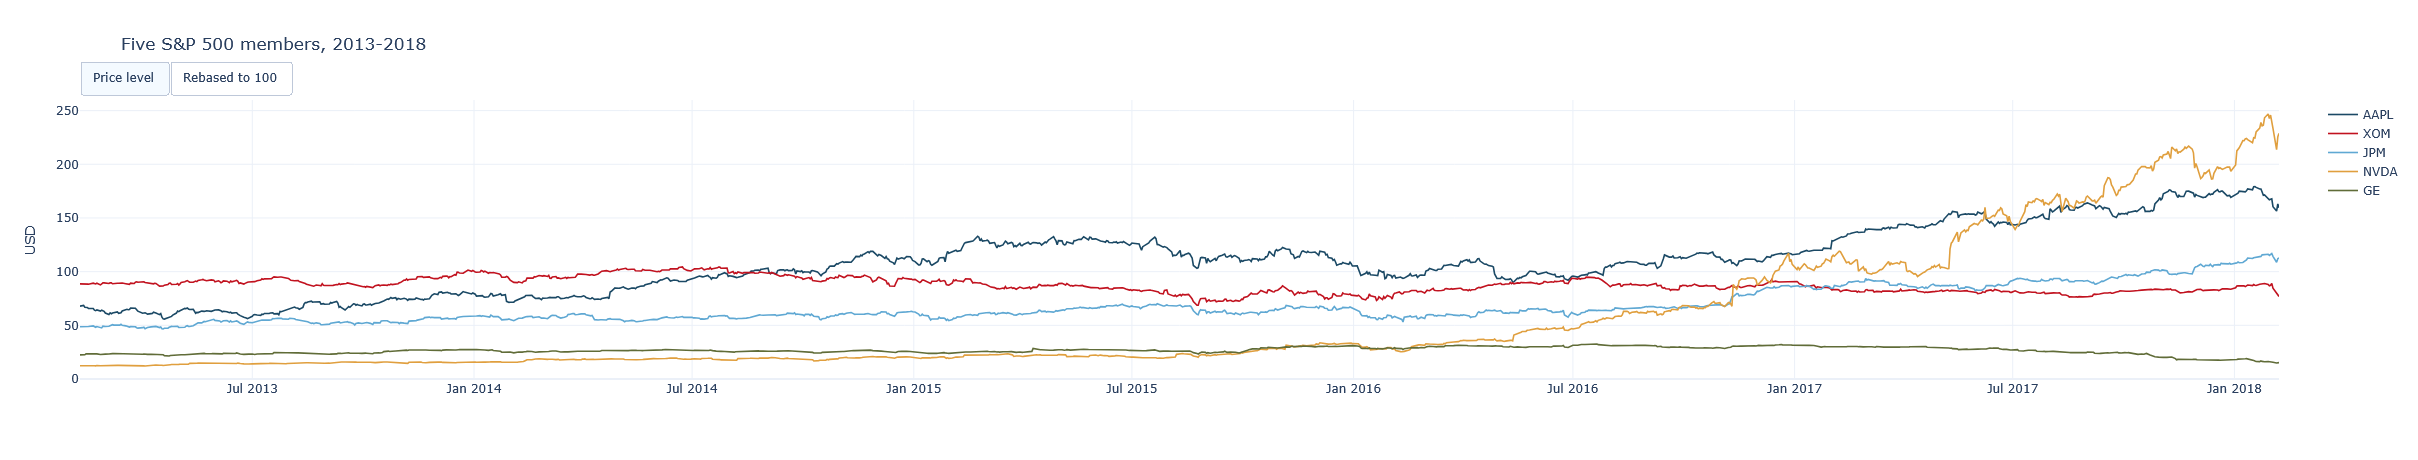

In [26]:
def plot_paths(price_matrix, tickers, title="Price paths"):
    """Interactive comparison of price paths, with a raw/rebased toggle."""
    rebased = price_matrix[tickers] / price_matrix[tickers].iloc[0] * 100
    fig = go.Figure()

    for i, tk in enumerate(tickers):                       # raw traces
        fig.add_trace(go.Scatter(x=price_matrix.index, y=price_matrix[tk], name=tk,
                                 line=dict(color=AIRM_COLOURS[i % len(AIRM_COLOURS)], width=1.6),
                                 visible=True))
    for i, tk in enumerate(tickers):                       # rebased traces
        fig.add_trace(go.Scatter(x=rebased.index, y=rebased[tk], name=tk,
                                 line=dict(color=AIRM_COLOURS[i % len(AIRM_COLOURS)], width=1.6),
                                 visible=False))

    n = len(tickers)
    fig.update_layout(
        title=title, template=AIRM_TEMPLATE, height=460,
        hovermode="x unified", yaxis_title="USD",
        updatemenus=[dict(
            type="buttons", direction="right", x=0, y=1.14, xanchor="left",
            buttons=[
                dict(label="Price level", method="update",
                     args=[{"visible": [True]*n + [False]*n},
                           {"yaxis": {"title": "USD"}}]),
                dict(label="Rebased to 100", method="update",
                     args=[{"visible": [False]*n + [True]*n},
                           {"yaxis": {"title": "Index (start = 100)"}}]),
            ])])
    return fig

# feel free to add more tickers to the list below...
plot_paths(prices, ["AAPL", "XOM", "JPM", "NVDA", "GE"],
           "Five S&P 500 members, 2013-2018").show()

Two things are worth noticing, and they set up everything that follows.

**First**, the price level tells you almost nothing. A $\$1,000$ share is not "expensive"
and a $\$5$ share is not "cheap" — the price depends on how many shares the company chose to
issue. Only the *rebased* view lets you compare, and that is why almost all quantitative
work is done on **returns** rather than prices.

**Second**, and more subtly: every one of those five companies is still recognisable
today. None of them went bankrupt. None were quietly delisted. Is that because the S&P
500 is full of indestructible companies, or because of how this list was assembled?

Keep that question live.

---

## 2. A perfectly reasonable strategy

We will use **momentum**: buy the stocks that have gone up the most recently. It is one of
the oldest and best-documented anomalies in finance, it appears in essentially every asset
class, and it is simple enough that we can be certain any strange result is not the
model's fault.

The rules:

| | |
|---|---|
| **Universe** | the 505 stocks in our file |
| **Signal** | total return over the past 6 months |
| **Portfolio** | buy the top 20% (about 100 stocks), equally weighted |
| **Rebalance** | monthly |
| **Benchmark** | equal-weighted portfolio of the whole universe |

The benchmark matters. A strategy that returns 12% a year sounds excellent until you learn
the universe itself returned 12% a year — at which point you have done all that work to
achieve nothing. **Always measure against the dumbest possible alternative.**

First, some functions. (You met `def` already; from here on we use it constantly,
because a backtest you can re-run with one argument changed is a backtest you can actually
learn from.)

In [27]:
def to_month_end(df):
    """Take the last observation in each calendar month.

    pandas renamed the month-end frequency from 'M' to 'ME' in version 2.2, and removed
    'M' in 3.0. This wrapper works on either. You will hit this kind of library churn
    constantly -- write the compatibility shim once and forget about it.
    """
    try:
        return df.resample("ME").last()
    except ValueError:
        return df.resample("M").last()


def monthly_returns(price_matrix):
    """Simple monthly returns. fill_method=None stops pandas from silently carrying
    a stale price across a gap, which would fabricate a return of exactly zero."""
    return to_month_end(price_matrix).pct_change(fill_method=None)


def momentum_signal(rets, lookback=6, skip=1, extra_lag=0, use_lookahead=False):
    """Cumulative return over `lookback` months, correctly lagged.

    skip       : ignore the most recent month (standard practice -- it is dominated by
                 short-term reversal, which works against momentum)
    extra_lag  : additional delay between forming the signal and being able to trade it
    use_lookahead : if True, deliberately introduces look-ahead bias. Never do this
                 outside a teaching notebook.
    """
    cum = (1 + rets).rolling(lookback).apply(np.prod, raw=True) - 1
    if use_lookahead:
        return cum                       # includes THIS month's return. Cheating.
    return cum.shift(1 + skip + extra_lag)


def backtest(rets, signal, top_pct=0.20, cost_bps=0.0, min_stocks=50):
    """Long-only, equally-weighted top-quantile portfolio, rebalanced monthly.

    Returns a DataFrame with the strategy's gross return, its return net of trading
    costs, its turnover, and the equal-weighted benchmark.
    """
    rows, w_prev = [], None
    for t in rets.index:
        s = signal.loc[t].dropna()
        r = rets.loc[t].dropna()
        s = s[s.index.isin(r.index)]                 # only tradable stocks
        if len(s) < min_stocks:
            continue

        n_hold = max(int(len(s) * top_pct), 1)
        held = s.nlargest(n_hold).index

        w = pd.Series(0.0, index=rets.columns)
        w[held] = 1.0 / n_hold
        turnover = 0.0 if w_prev is None else (w - w_prev).abs().sum()
        w_prev = w

        gross = r[held].mean()
        rows.append({"date": t,
                     "gross": gross,
                     "net": gross - turnover * cost_bps / 1e4,
                     "turnover": turnover,
                     "benchmark": r.mean(),
                     "n_stocks": len(s)})
    return pd.DataFrame(rows).set_index("date")


def performance(returns, periods_per_year=12):
    """Headline statistics for a return series."""
    r = returns.dropna()
    growth = (1 + r).prod()
    years = len(r) / periods_per_year
    cagr = growth ** (1 / years) - 1
    vol = r.std() * np.sqrt(periods_per_year)
    curve = (1 + r).cumprod()
    max_dd = (curve / curve.cummax() - 1).min()
    return {"CAGR": cagr, "Volatility": vol,
            "Sharpe": r.mean() / r.std() * np.sqrt(periods_per_year),
            "Max drawdown": max_dd, "Months": len(r)}


def show_performance(named_series):
    """Format a dict of {label: return series} as a comparison table."""
    return (pd.DataFrame({k: performance(v) for k, v in named_series.items()}).T
              .style.format({"CAGR": "{:.2%}", "Volatility": "{:.2%}",
                             "Sharpe": "{:.2f}", "Max drawdown": "{:.2%}",
                             "Months": "{:.0f}"}))

print("Functions defined.")

Functions defined.


### Run it

In [28]:
rets = monthly_returns(prices)

# The version a hurried analyst writes on a Friday afternoon.
signal_naive = momentum_signal(rets, lookback=6, use_lookahead=True)
bt_naive = backtest(rets, signal_naive)

show_performance({"Momentum (naive)": bt_naive["gross"],
                  "Equal-weight benchmark": bt_naive["benchmark"]})

,CAGR,Volatility,Sharpe,Max drawdown,Months
Momentum (naive),62.49%,11.64%,4.31,-3.90%,55
Equal-weight benchmark,11.82%,10.21%,1.15,-10.03%,55


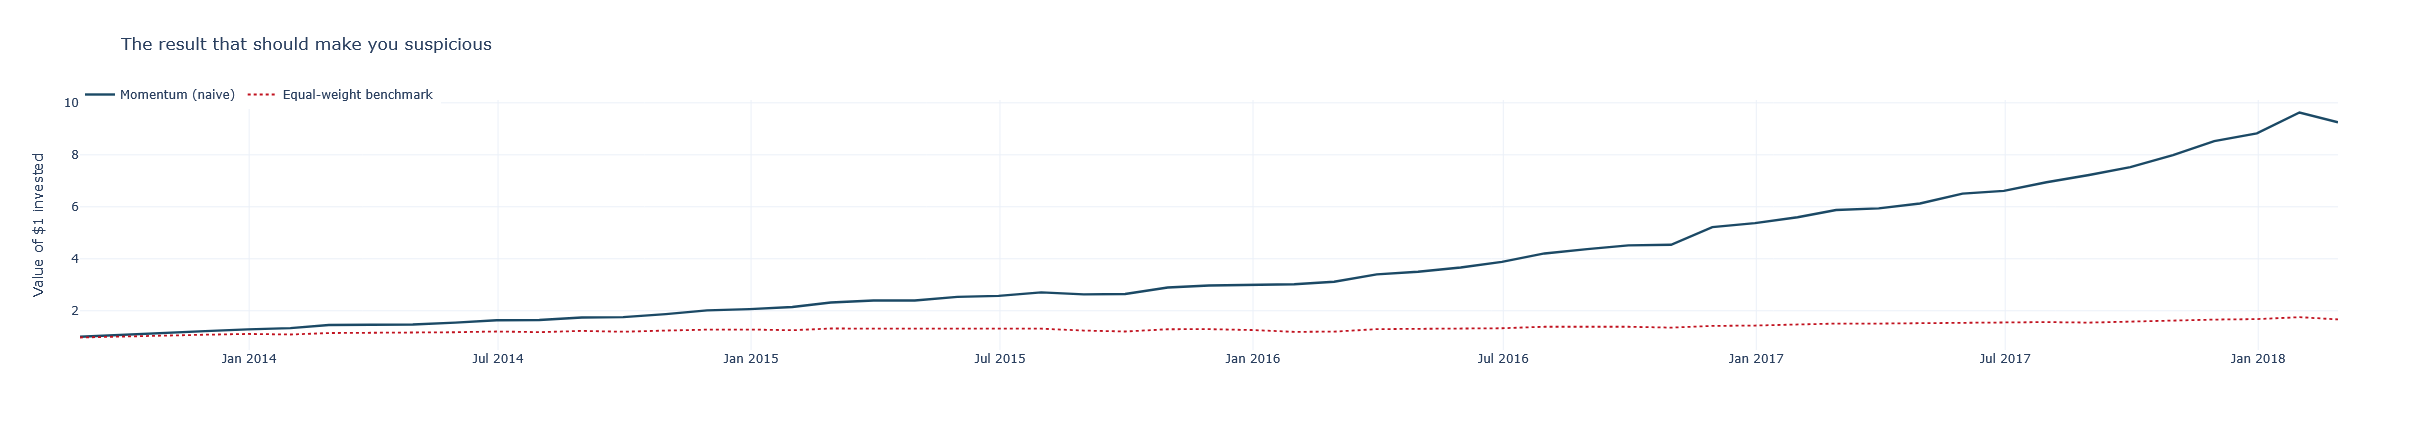

In [29]:
def plot_equity(named_series, title="Growth of $1"):
    fig = go.Figure()
    for i, (label, s) in enumerate(named_series.items()):
        curve = (1 + s.dropna()).cumprod()
        fig.add_trace(go.Scatter(x=curve.index, y=curve, name=label,
                                 line=dict(color=AIRM_COLOURS[i % len(AIRM_COLOURS)],
                                           width=2.4 if i == 0 else 1.8,
                                           dash=None if i == 0 else "dot")))
    fig.update_layout(title=title, template=AIRM_TEMPLATE, height=430,
                      yaxis_title="Value of $1 invested", hovermode="x unified",
                      legend=dict(orientation="h", y=1.08, x=0))
    return fig

plot_equity({"Momentum (naive)": bt_naive["gross"],
             "Equal-weight benchmark": bt_naive["benchmark"]},
            "The result that should make you suspicious").show()

### Stop. Something is wrong.

A Sharpe ratio above 4 is not a good result. It is a **diagnostic**.

To put that number in context: Renaissance Technologies' Medallion fund, the most
successful quantitative fund ever operated, is estimated to have run at a Sharpe of
roughly 2 over three decades. Warren Buffett's long-run Sharpe is about 0.8. A brand new
hedge fund launching with a claimed Sharpe of 1.5 will raise money comfortably.

We have just written thirty lines of pandas and apparently doubled Medallion.

This is the single most useful reflex to build in this entire course:

> **An extraordinary backtest result is almost never evidence of an extraordinary
> strategy. It is evidence of a bug.**

The rest of this notebook is us hunting the bug. There are three, and none of them is in
the strategy.

<details>
<summary><b>Why is a high Sharpe ratio so implausible?</b></summary>

If returns were independent across months, a strategy with true Sharpe $S$ observed over
$T$ years produces an estimate with standard error of roughly $\sqrt{(1 + S^2/2)/T}$.
With $T = 4.5$ years and an estimate of 4.3, the 95% confidence interval still comfortably
excludes anything below 2 — so this is not simply a lucky sample. The number is too large
to be noise, which means it must be structural. Something in the construction is feeding
the strategy information it could not have had.

There is a second, economic argument. A Sharpe of 4 permits enormous leverage at very low
risk of ruin. Any such opportunity attracts capital until the excess return is competed
away. Persistent Sharpe ratios above about 2 in liquid public equities are, on priors,
close to impossible.

</details>

---

## 3. Trap 1 — Look-ahead bias

**Look-ahead bias is using information you could not have had at the time you claim to
have acted on it.**

It is the most common error in quantitative finance and the hardest to see, because the
code that contains it looks completely normal. Ours is a single missing `.shift()`.

Here is the timeline. We form the portfolio at the end of January and hold it through
February. The signal is a 6-month return. The question is: **which six months?**

| | Sep | Oct | Nov | Dec | **Jan** | *Feb* |
|---|---|---|---|---|---|---|
| Honest signal | ✅ | ✅ | ✅ | ✅ | ✅ | — |
| Our signal | ✅ | ✅ | ✅ | ✅ | ✅ | ✅ ← **we used February's return to pick February's portfolio** |

The strategy was choosing stocks partly on the basis of how they were about to perform.
Of course it worked.

In [30]:
# Make the leak visible. For one stock, print what each signal version "knows".
tk = "AAPL"
demo = pd.DataFrame({
    "return this month":     rets[tk],
    "signal (look-ahead)":   momentum_signal(rets, use_lookahead=True)[tk],
    "signal (honest)":       momentum_signal(rets)[tk],
}).dropna().head(6)

print(f"{tk}: what each signal version knows at the point of trading\n")
print(demo.round(4).to_string())
print("\nThe honest signal is the same numbers, shifted down two rows: it can only use")
print("information from two months ago or earlier (one month to observe, one to skip).")

AAPL: what each signal version knows at the point of trading

            return this month  signal (look-ahead)  signal (honest)
date                                                               
2013-10-31             0.0964               0.1805           0.1038
2013-11-30             0.0638               0.2364           0.0770
2013-12-31             0.0089               0.4148           0.1805
2014-01-31            -0.1077               0.1062           0.2364
2014-02-28             0.0512               0.0801           0.4148
2014-03-31             0.0200               0.1258           0.1062

The honest signal is the same numbers, shifted down two rows: it can only use
information from two months ago or earlier (one month to observe, one to skip).


In [31]:
signal_honest = momentum_signal(rets, lookback=6, skip=1)     # the one-word fix
bt_honest = backtest(rets, signal_honest)

show_performance({"Momentum (look-ahead)":   bt_naive["gross"],
                  "Momentum (honest)":       bt_honest["gross"],
                  "Equal-weight benchmark":  bt_honest["benchmark"]})

,CAGR,Volatility,Sharpe,Max drawdown,Months
Momentum (look-ahead),62.49%,11.64%,4.31,-3.90%,55
Momentum (honest),14.54%,11.25%,1.27,-7.62%,53
Equal-weight benchmark,11.94%,10.12%,1.17,-10.03%,53


**Sharpe 4.31 → 1.27.** Seventy percent of the strategy's apparent quality was one missing
line of code.

A Sharpe of 1.27 is still a good result, though — a real fund would be pleased with it.
So have we found something? Not yet. We have two traps to go, and both of them live in the
question we parked earlier: *where did the list of 505 companies come from?*

---

## 4. Trap 2 — Survivorship and backfill bias

Our file is called "all stocks 5yr" and contains 505 tickers with data from February 2013.
That framing invites you to believe it is *the S&P 500 as it was in 2013*.

It is not. It is **the S&P 500 as it was in February 2018, with five years of history
attached to each of those companies.**

The difference is everything, and it produces two distinct biases:

**Survivorship bias.** Companies that were in the index in 2013 but went bankrupt, were
acquired, or were demoted before 2018 are simply not in the file. The failures have been
deleted from history. Our backtest never gets the chance to buy a company that is about
to collapse — because from its point of view, such companies do not exist.

**Backfill bias.** Companies that were *added* to the index between 2013 and 2018 appear
in the data from day one. But firms get promoted into the S&P 500 by growing — so these
are, almost by construction, the winners of that period. We have handed our 2013 strategy
a shopping list of stocks that had not yet succeeded.

We can prove the second one exactly, using a second public file that records when each
company joined the index.

In [32]:
constituents = pd.read_csv(fetch("constituents.csv"), parse_dates=["Date added"])
constituents = constituents.rename(columns={"Symbol": "ticker", "Date added": "joined"})

panel_start = prices.index.min()
in_panel = set(prices.columns)

# Which stocks in our price file joined the index AFTER our backtest begins?
backfilled = constituents[constituents["ticker"].isin(in_panel)
                          & (constituents["joined"] > panel_start)]

print(f"Stocks in the price file            : {len(in_panel)}")
print(f"...that joined the index after {panel_start:%b %Y} : {len(backfilled)}")
print(f"\nA sample of the stocks our 2013 backtest should not have been able to see:\n")
print(backfilled.sort_values("joined")[["ticker", "Security", "GICS Sector", "joined"]]
      .head(10).to_string(index=False))

Stocks in the price file            : 505
...that joined the index after Feb 2013 : 76

A sample of the stocks our 2013 backtest should not have been able to see:

ticker                  Security            GICS Sector     joined
  REGN Regeneron Pharmaceuticals            Health Care 2013-05-01
    GM            General Motors Consumer Discretionary 2013-06-06
   ZTS                    Zoetis            Health Care 2013-06-21
  NWSA       News Corp (Class A) Communication Services 2013-08-01
   DAL           Delta Air Lines            Industrials 2013-09-11
   AME                    Ametek            Industrials 2013-09-23
  VRTX    Vertex Pharmaceuticals            Health Care 2013-09-23
  ALLE                  Allegion            Industrials 2013-12-02
  TSCO            Tractor Supply Consumer Discretionary 2014-01-24
   ESS      Essex Property Trust            Real Estate 2014-04-02


Seventy-six of them. And look at the names: Broadcom, Alphabet's Class C shares, Delta Air
Lines, General Motors, Vertex, Regeneron. These are some of the great success stories of
the 2010s, and every one of them is sitting in our 2013 investable universe because we
already know how the decade turned out.

Let us take them out and re-run. Nothing about the strategy changes — only the list of
stocks it is allowed to consider.

In [33]:
clean_universe = [t for t in rets.columns if t not in set(backfilled["ticker"])]
rets_clean = rets[clean_universe]

bt_clean = backtest(rets_clean, momentum_signal(rets_clean, lookback=6, skip=1))

show_performance({"Momentum (honest signal, biased universe)": bt_honest["gross"],
                  "Momentum (honest signal, clean universe)":  bt_clean["gross"],
                  "Equal-weight benchmark (clean universe)":   bt_clean["benchmark"]})

,CAGR,Volatility,Sharpe,Max drawdown,Months
"Momentum (honest signal, biased universe)",14.54%,11.25%,1.27,-7.62%,53
"Momentum (honest signal, clean universe)",12.25%,11.10%,1.10,-8.41%,53
Equal-weight benchmark (clean universe),10.91%,10.12%,1.08,-10.88%,53


Another chunk gone. And notice it is not only the strategy that falls — the *benchmark*
falls too. The bias was never about momentum. It inflated the whole dataset.

That difference in the benchmark is the honest measure of the damage: it is the return you
would appear to earn by doing nothing at all, purely because of how the universe was
assembled. Roughly one percentage point a year. For context, the median active equity
manager fails to beat their benchmark by rather less than that.

### What free data can never show you

We have removed the backfilled winners. We have **not** fixed survivorship, and with this
dataset we cannot: the companies that died between 2013 and 2018 are not in the file, so
there is nothing to add back. Kodak, Sears, Frontier Communications, RadioShack — they were
in the index, they collapsed, and free datasets quietly forget them.

Fixing this properly requires point-in-time index membership data, which is why CRSP and
Compustat licences cost what they do, and why "I got the data off the internet" is a
legitimate reason to distrust a backtest.

But we can measure how much it matters, by building a small world where we control the
truth. Below we simulate 500 firms over ten years. Firms can go bankrupt; bankruptcy is
more likely after poor performance, and a failing firm loses 45% in its final month. We
then run the identical backtest twice: once on the full universe, and once on only the
firms that were still alive at the end — exactly the mistake our real dataset makes for us.

In [34]:
def simulate_universe(n_firms=500, n_months=120, seed=21,
                      market_mean=0.008, market_vol=0.038, idio_vol=0.075,
                      base_hazard=0.003, failure_return=-0.45):
    """A synthetic equity market in which firms can die.

    Each firm's return is a market component (scaled by its beta) plus idiosyncratic
    noise. Each month, surviving firms face a bankruptcy hazard that rises sharply when
    trailing performance is poor. A firm that fails loses `failure_return` and then
    disappears from the data.

    Returns (returns DataFrame, boolean array flagging the firms that died).
    """
    rng = np.random.default_rng(seed)
    market = rng.normal(market_mean, market_vol, n_months)
    beta = rng.normal(1.0, 0.35, n_firms).clip(0.2, 2.2)
    idio = rng.normal(0.0, idio_vol, (n_months, n_firms))

    R = pd.DataFrame(market[:, None] * beta[None, :] + idio,
                     columns=[f"FIRM{i:03d}" for i in range(n_firms)])

    alive = np.ones(n_firms, dtype=bool)
    for t in range(12, n_months):
        trailing = (1 + R.iloc[t - 12:t]).prod().values - 1
        hazard = base_hazard * np.exp(-3.0 * np.clip(trailing, -0.9, 2.0))
        fails = alive & (rng.random(n_firms) < hazard)
        R.iloc[t, fails] = failure_return
        R.iloc[t + 1:, fails] = np.nan
        alive &= ~fails

    return R, ~alive


sim_rets, died = simulate_universe()
print(f"Firms simulated : {sim_rets.shape[1]}")
print(f"Firms that failed: {died.sum()} ({died.mean():.0%} over ten years, "
      f"about {died.mean()/10:.1%} a year)")
print(f"Firms surviving  : {(~died).sum()}  <-- the only ones a free dataset would contain")

Firms simulated : 500
Firms that failed: 143 (29% over ten years, about 2.9% a year)
Firms surviving  : 357  <-- the only ones a free dataset would contain


In [13]:
def run_sim_backtest(returns_frame):
    sig = momentum_signal(returns_frame, lookback=6, skip=1)
    return backtest(returns_frame, sig)

bt_truth    = run_sim_backtest(sim_rets)                     # reality
bt_survivor = run_sim_backtest(sim_rets.loc[:, ~died])       # what you would have seen

show_performance({
    "TRUTH: full universe, failures included": bt_truth["benchmark"],
    "BIASED: survivors only":                  bt_survivor["benchmark"],
    "TRUTH: momentum strategy":                bt_truth["gross"],
    "BIASED: momentum strategy":               bt_survivor["gross"],
})

,CAGR,Volatility,Sharpe,Max drawdown,Months
"TRUTH: full universe, failures included",7.85%,12.25%,0.68,-19.95%,113
BIASED: survivors only,10.59%,12.39%,0.88,-18.12%,113
TRUTH: momentum strategy,8.15%,12.90%,0.67,-18.12%,113
BIASED: momentum strategy,9.55%,12.86%,0.78,-18.46%,113


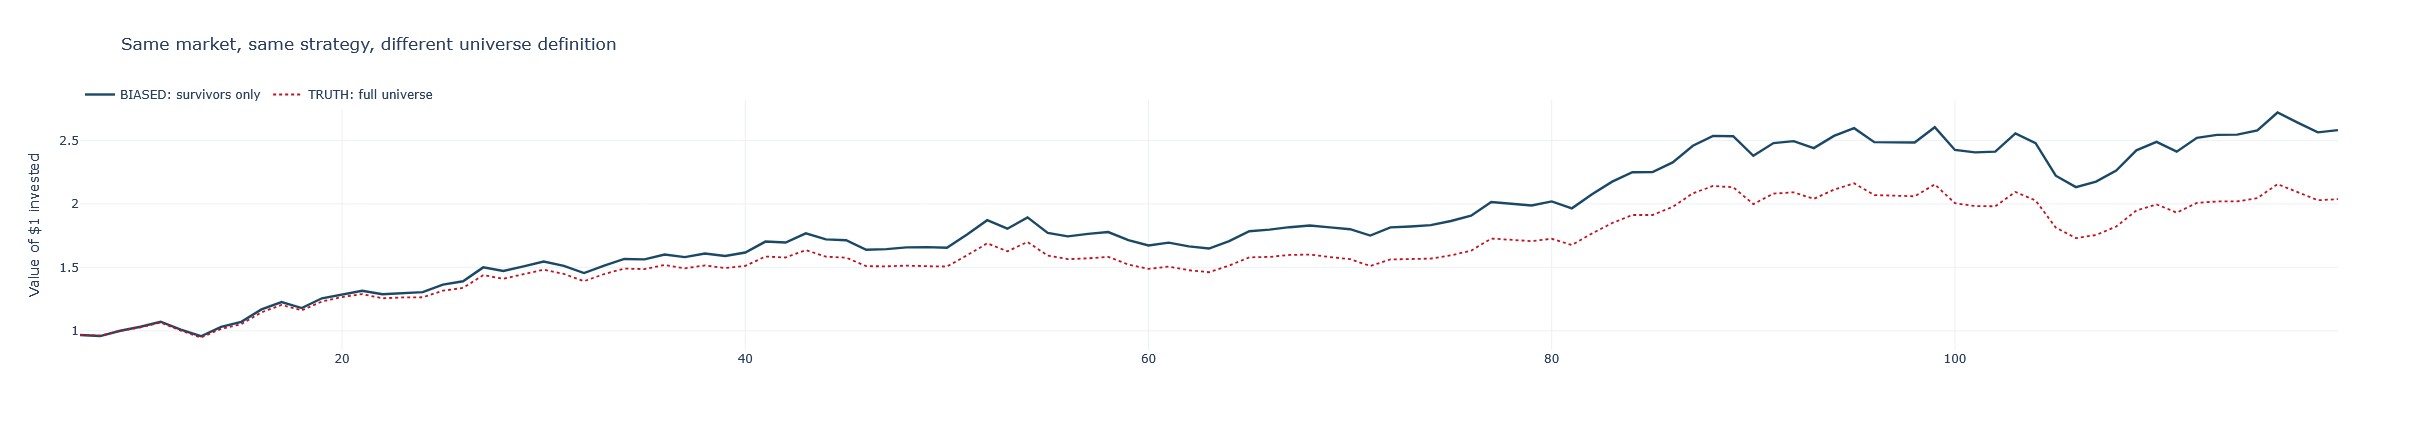

Phantom return created purely by deleting the failures: +2.74% per year


In [35]:
plot_equity({"BIASED: survivors only":  bt_survivor["benchmark"],
             "TRUTH: full universe":    bt_truth["benchmark"]},
            "Same market, same strategy, different universe definition").show()

gap = (performance(bt_survivor["benchmark"])["CAGR"]
       - performance(bt_truth["benchmark"])["CAGR"])
print(f"Phantom return created purely by deleting the failures: {gap:+.2%} per year")

Nearly three percentage points a year of pure fiction, compounding into a visibly
different wealth path — and remember, **the strategy is identical in both lines**. The
only difference is which companies the dataset chose to remember.

Empirical estimates of survivorship bias in real equity databases typically land between
1% and 4% a year depending on the universe, with the effect worst in small caps, emerging
markets and hedge fund databases (where reporting is voluntary, so failing funds simply
stop reporting). Our simulation is squarely in that range.

<details>
<summary><b>Why does the bias inflate returns rather than just adding noise?</b></summary>

Deleting firms is not random sampling — it is sampling *conditional on the outcome*. The
probability that a firm appears in the final dataset is an increasing function of its
realised returns, so

$$\mathbb{E}[r \mid \text{survived}] > \mathbb{E}[r]$$

This is a selection effect, and it is the same mathematical structure as the mutual fund
industry's habit of merging away its worst performers, the "returns of a typical
entrepreneur" statistic, and the wartime problem of only being able to inspect the
aeroplanes that made it home.

The bias also *compresses measured risk*: the deleted observations are disproportionately
the far-left tail, so volatility, skewness and drawdown estimates all look far more
comfortable than the truth. For a risk model — the subject of Lecture 6 — that second
distortion is the more dangerous of the two.

</details>

---

## 5. Trap 3 — The gap between a signal and a trade

The last two traps were about information. This one is about physics.

Our backtest assumes we observe the month-end price and simultaneously trade at that
price, free of charge. Neither is true.

**You cannot trade at the closing price you used to make the decision.** Data arrives,
gets cleaned, gets fed to the model, the model runs, a human approves it, orders route to
the market. For a monthly strategy at a real institution that is at minimum a day and
realistically longer. We will apply a conservative one-month delay.

**Trading is not free.** Commission, exchange fees, the bid-ask spread, and — usually
largest of all — market impact, the price move you cause by buying. For liquid US large
caps at institutional size, 20 basis points for a round trip is a reasonable estimate.
It sounds trivial. Our strategy turns over about 60% of the portfolio every month, so it
is being charged roughly twelve times a year.

In [36]:
signal_lagged = momentum_signal(rets_clean, lookback=6, skip=1, extra_lag=1)

bt_lagged = backtest(rets_clean, signal_lagged)                   # delay only
bt_costed = backtest(rets_clean, signal_lagged, cost_bps=20)      # delay + costs

print(f"Average monthly turnover: {bt_costed['turnover'].mean():.0%} of the portfolio")
print(f"Implied annual cost drag: {bt_costed['turnover'].mean() * 12 * 20 / 1e4:.2%}\n")

show_performance({"Clean universe, no delay":     bt_clean["gross"],
                  "+ one month execution delay":  bt_lagged["gross"],
                  "+ 20bp round-trip costs":      bt_costed["net"],
                  "Equal-weight benchmark":       bt_costed["benchmark"]})

Average monthly turnover: 63% of the portfolio
Implied annual cost drag: 1.50%



,CAGR,Volatility,Sharpe,Max drawdown,Months
"Clean universe, no delay",12.25%,11.10%,1.10,-8.41%,53
+ one month execution delay,11.73%,11.57%,1.02,-8.02%,52
+ 20bp round-trip costs,10.07%,11.57%,0.89,-8.40%,52
Equal-weight benchmark,10.07%,10.09%,1.00,-10.88%,52


---

## 6. The realism ladder

Let us put the whole descent in one place. Each rung fixes one flaw. **The strategy logic
never changes.**

In [37]:
ladder = {
    "0. Look-ahead signal, biased universe": bt_naive["gross"],
    "1. Fix look-ahead":                     bt_honest["gross"],
    "2. Remove backfilled winners":          bt_clean["gross"],
    "3. Add execution delay":                bt_lagged["gross"],
    "4. Add trading costs":                  bt_costed["net"],
}
benchmark = bt_costed["benchmark"]

summary = pd.DataFrame({k: performance(v) for k, v in ladder.items()}).T
summary["Excess over benchmark"] = summary["CAGR"] - performance(benchmark)["CAGR"]
summary[["CAGR", "Volatility", "Sharpe", "Max drawdown", "Excess over benchmark"]].style.format(
    {"CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
     "Max drawdown": "{:.2%}", "Excess over benchmark": "{:+.2%}"})

,CAGR,Volatility,Sharpe,Max drawdown,Excess over benchmark
"0. Look-ahead signal, biased universe",62.49%,11.64%,4.31,-3.90%,+52.42%
1. Fix look-ahead,14.54%,11.25%,1.27,-7.62%,+4.47%
2. Remove backfilled winners,12.25%,11.10%,1.10,-8.41%,+2.18%
3. Add execution delay,11.73%,11.57%,1.02,-8.02%,+1.65%
4. Add trading costs,10.07%,11.57%,0.89,-8.40%,-0.00%


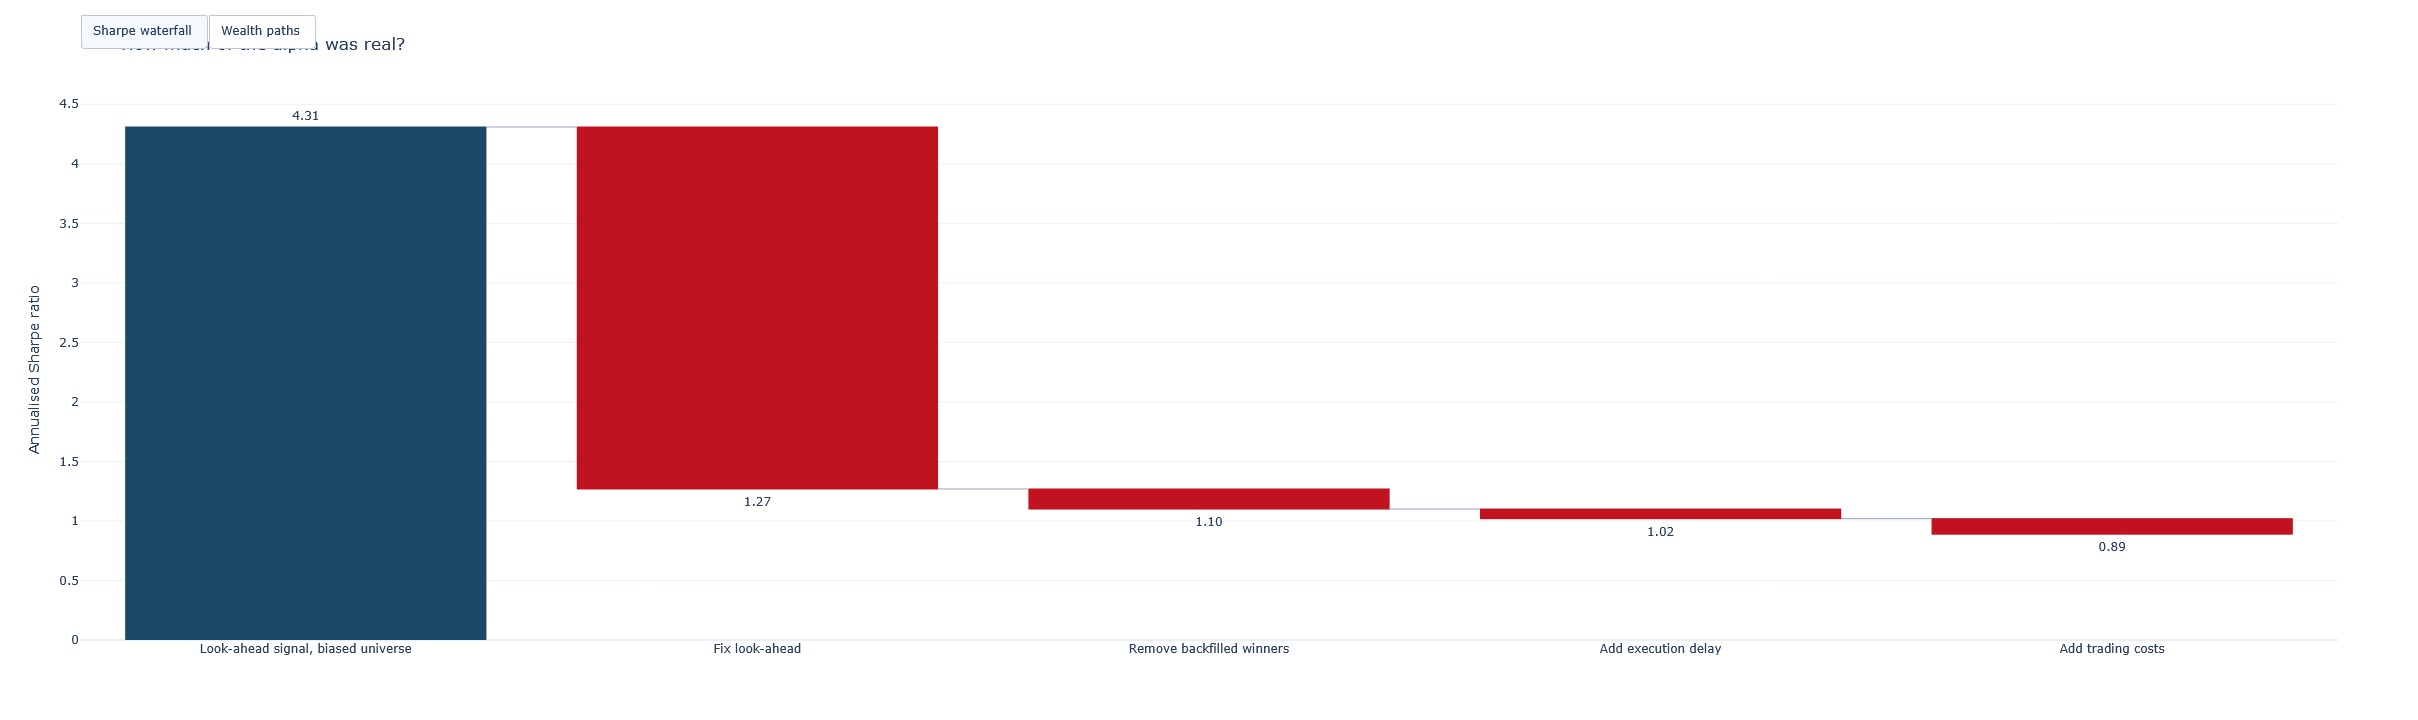

In [49]:
def plot_ladder(ladder_dict, benchmark_series):
    """Waterfall of Sharpe destruction, plus the matching wealth paths on a second tab."""
    labels = list(ladder_dict)
    sharpes = [performance(s)["Sharpe"] for s in ladder_dict.values()]
    steps = [sharpes[0]] + list(np.diff(sharpes))

    fig = go.Figure()
    fig.add_trace(go.Waterfall(
        x=[l.split(". ")[1] for l in labels], y=steps,
        measure=["absolute"] + ["relative"] * (len(labels) - 1),
        text=[f"{s:.2f}" for s in sharpes], textposition="outside",
        connector=dict(line=dict(color="#94a3b8", width=1)),
        increasing=dict(marker=dict(color="#606c38")),
        decreasing=dict(marker=dict(color="#c1121f")),
        totals=dict(marker=dict(color="#1b4965")), visible=True))

    for i, (label, s) in enumerate(ladder_dict.items()):
        curve = (1 + s.dropna()).cumprod()
        fig.add_trace(go.Scatter(x=curve.index, y=curve, name=label, visible=False,
                                 line=dict(color=AIRM_COLOURS[i % len(AIRM_COLOURS)], width=2)))
    bench = (1 + benchmark_series.dropna()).cumprod()
    fig.add_trace(go.Scatter(x=bench.index, y=bench, name="Benchmark", visible=False,
                             line=dict(color="#334155", width=2, dash="dash")))
    n_curves = len(ladder_dict) + 1
    fig.update_layout(
        template=AIRM_TEMPLATE, height=720, showlegend=False,
        title="How much of the alpha was real?",
        yaxis_title="Annualised Sharpe ratio",
        updatemenus=[dict(
            type="buttons", direction="right", x=0, y=1.16, xanchor="left",
            buttons=[
                dict(label="Sharpe waterfall", method="update",
                     args=[{"visible": [True] + [False] * n_curves},
                           {"yaxis": {"title": "Annualised Sharpe ratio"},
                            "showlegend": False}]),
                dict(label="Wealth paths", method="update",
                     args=[{"visible": [False] + [True] * n_curves},
                           {"yaxis": {"title": "Value of $1 invested"},
                            "showlegend": True}]),
            ])])

    return fig

plot_ladder(ladder, benchmark).show()

### The verdict on today's claim

> **"Better features make better decisions."**

**Not proven — and not even testable until the data is honest.**

Look at the bottom row of the summary table against the benchmark. After removing the
look-ahead, the backfilled winners, the impossible execution and the free trading, our
momentum strategy returns **10.07% a year — and the equal-weighted benchmark returns
10.07% a year.** The strategy achieves it with more volatility, so its Sharpe ratio of
0.89 is actually *worse* than the benchmark's 1.00.

We have not merely failed to add value. We have destroyed it, while incurring the costs of
a research team, a trading desk and a monthly rebalance.

Everything that looked like skill was an artefact of data construction. And here is the
part that should worry you: **the model was never the problem.** We could have replaced
momentum with a deep neural network at rung 0 and it would have reported a Sharpe of 4 as
well, for exactly the same reasons. All the sophistication in the world sits downstream of
the question "is my dataset telling me the truth?"

This is why we start the course here rather than with the models.

<details>
<summary><b>Was the strategy itself really worthless? A note on the sample period</b></summary>

Be careful about over-generalising. 2013–2018 was a poor period for momentum — the
February 2016 reversal was one of the sharpest momentum drawdowns on record, and our
four-and-a-half-year test contains roughly one such event.

With 53 monthly observations, the standard error on our Sharpe estimate is around 0.5.
So the honest statement is not "momentum does not work"; it is **"this test cannot tell
us whether momentum works"**. Distinguishing a Sharpe of 0.3 from a Sharpe of 0 at
conventional significance takes decades of data.

That is a genuinely uncomfortable feature of this field, and we return to it in Lecture 5
when we look at how easily backtests can be overfitted.

</details>

---

## 7. Now that the data is honest — do features help?

We have spent six sections demolishing things. Let us build something.

A **feature** is any number computed from the information available at time $t$ that you
think might carry information about what happens next. In a cross-sectional equity
problem, the input to your model is a table with one row per stock per month and one
column per feature. Everything a machine learning model can possibly know about a company
is in that row.

We will construct four features from nothing but prices and volumes:

| Feature | Definition | Economic story |
|---|---|---|
| `mom_6m` | return over months $t-6$ to $t-1$ | trends persist |
| `reversal_1m` | *minus* last month's return | last month's losers bounce |
| `vol_3m` | volatility of daily returns, past 3 months | low-risk stocks have historically outperformed |
| `high_52w` | price ÷ highest price in past year | proximity to a 52-week high anchors investors |

Each is a well-documented anomaly. None requires anything more exotic than the data we
already loaded.

In [51]:
def build_features(price_matrix, volume_matrix):
    """Construct a monthly cross-sectional feature panel from daily prices and volumes.

    Every feature is lagged so that a value dated month t uses only information
    observable by the end of month t. Nothing here can see the future.
    """
    daily_ret = price_matrix.pct_change(fill_method=None)
    monthly = monthly_returns(price_matrix)

    mom_6m = ((1 + monthly).rolling(6).apply(np.prod, raw=True) - 1).shift(1)
    reversal_1m = -monthly.shift(0)
    vol_3m = to_month_end(daily_ret.rolling(63).std()) * np.sqrt(252)
    high_52w = to_month_end(price_matrix / price_matrix.rolling(252).max())

    features = {"mom_6m": mom_6m, "reversal_1m": reversal_1m,
                "vol_3m": vol_3m, "high_52w": high_52w}

    # Lag every feature by one month: a feature dated t is only usable to trade t+1.
    return {name: f.shift(1) for name, f in features.items()}


features = build_features(prices[clean_universe], volumes[clean_universe])

print("Feature panel built. Snapshot for one month:\n")
snapshot = pd.DataFrame({k: v.loc["2016-06-30"] for k, v in features.items()})
print(snapshot.dropna().head(8).round(3).to_string())

Feature panel built. Snapshot for one month:

        mom_6m  reversal_1m  vol_3m  high_52w
ticker                                       
A        0.084       -0.121   0.197     1.000
AAL     -0.249        0.080   0.288     0.686
AAP     -0.213        0.014   0.229     0.768
AAPL    -0.216       -0.065   0.232     0.756
ABBV     0.024       -0.032   0.218     0.883
ABC     -0.118        0.119   0.253     0.652
ABT     -0.132       -0.019   0.232     0.774
ACN      0.053       -0.054   0.177     0.999


### Why raw features are unusable

Look at the ranges above. `vol_3m` is around 0.2, `high_52w` is around 0.95, `mom_6m`
might be anything from −0.4 to +2.0. Any model that weights features — a linear
regression, a neural network, a distance-based method — will be dominated by whichever
feature happens to have the largest numbers.

Worse, the ranges *drift*. Volatility in a calm month and volatility in March 2020 are not
the same variable. A model trained on one will be badly calibrated for the other.

The standard fix is to convert each feature into a **cross-sectional score**: forget the
absolute level, ask only where this stock sits relative to the others *this month*. Three
ways to do it, in increasing robustness:

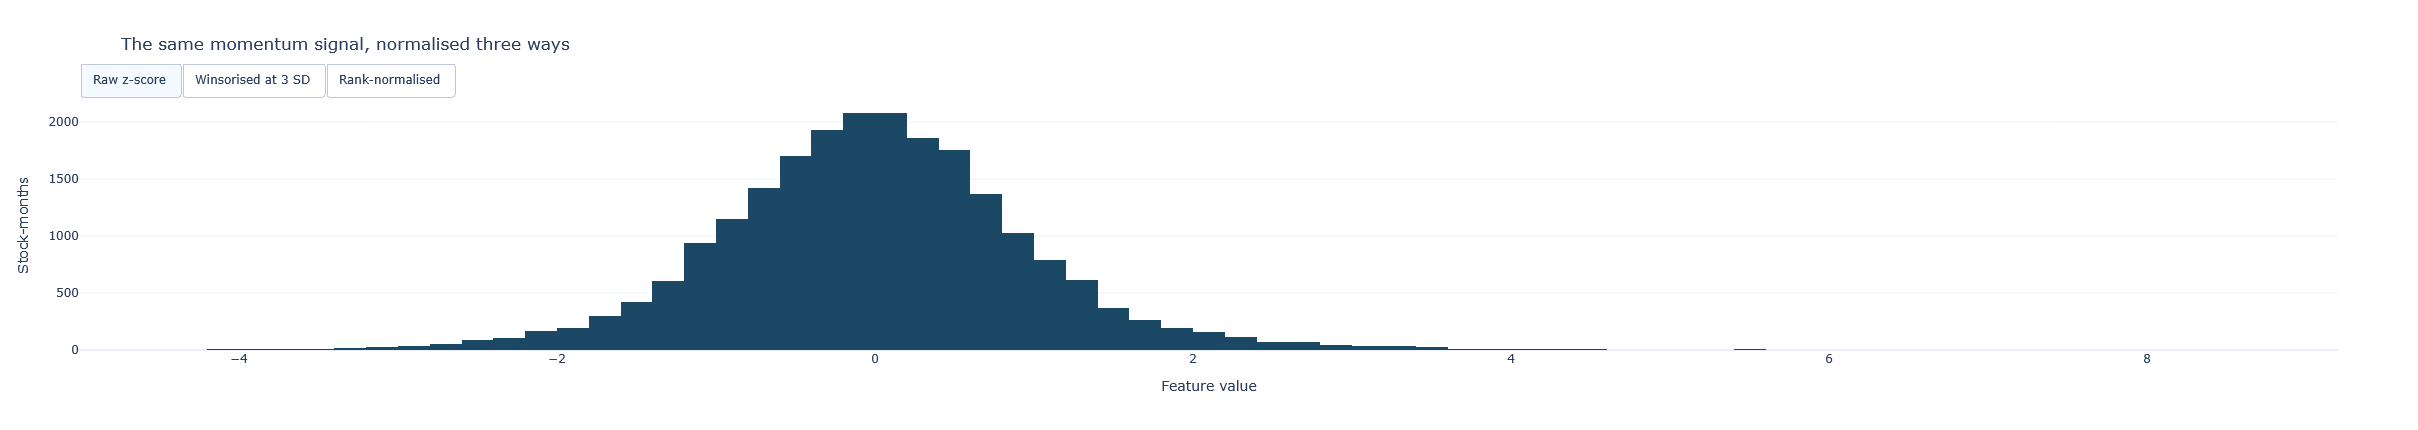

Most extreme raw z-score in the sample: 9.2 standard deviations


In [52]:
def cross_sectional_zscore(frame):
    """Standardise each row: (x - row mean) / row standard deviation."""
    return frame.sub(frame.mean(axis=1), axis=0).div(frame.std(axis=1), axis=0)


def winsorise(frame, limit=3.0):
    """Clip extreme z-scores. Blunts the influence of data errors and genuine freaks."""
    return frame.clip(lower=-limit, upper=limit)


def cross_sectional_rank(frame):
    """Replace values by their rank within the month, scaled to [-0.5, +0.5].

    This discards the magnitude entirely and keeps only the ordering, which makes it
    immune to outliers and to changes in the shape of the distribution over time.
    """
    return frame.rank(axis=1, pct=True) - 0.5


raw_z = cross_sectional_zscore(features["mom_6m"])
versions = {
    "Raw z-score":        raw_z,
    "Winsorised at 3 SD": winsorise(raw_z),
    "Rank-normalised":    cross_sectional_rank(features["mom_6m"]),
}

fig = go.Figure()
for i, (label, frame) in enumerate(versions.items()):
    vals = frame.stack().dropna().values
    fig.add_trace(go.Histogram(x=vals, name=label, nbinsx=80, visible=(i == 0),
                               marker=dict(color=AIRM_COLOURS[i])))

fig.update_layout(
    title="The same momentum signal, normalised three ways",
    template=AIRM_TEMPLATE, height=430, showlegend=False,
    xaxis_title="Feature value", yaxis_title="Stock-months",
    updatemenus=[dict(type="buttons", direction="right", x=0, y=1.15, xanchor="left",
        buttons=[dict(label=lbl, method="update",
                      args=[{"visible": [j == i for j in range(len(versions))]}])
                 for i, lbl in enumerate(versions)])])
fig.show()

print(f"Most extreme raw z-score in the sample: {raw_z.stack().abs().max():.1f} standard deviations")

Flip between the three views. The raw z-scores have a long right tail reaching past nine
standard deviations — one stock, in one month, would carry more weight in a linear model
than several hundred ordinary observations combined. Winsorising truncates it. Ranking
removes the question entirely by throwing the magnitudes away.

Which to use is a genuine modelling decision, not a formality. Ranking is safest and is
standard for building portfolios. But it destroys information: it cannot distinguish a
stock that beat the field by 1% from one that beat it by 60%, and if that magnitude
carries signal, you have discarded it.

<details>
<summary><b>Cross-sectional vs time-series standardisation</b></summary>

Note that we standardise *across stocks within a month* (`axis=1`), not across time within
a stock. The distinction is critical.

Standardising down the time axis uses the full-sample mean and standard deviation of each
stock — including months after the date you are standardising. That is look-ahead bias,
reintroduced by the back door, and it is one of the most common ways it sneaks into
otherwise careful pipelines. `sklearn`'s `StandardScaler.fit_transform(X)` applied to a
whole time series does exactly this.

Cross-sectional standardisation has no such problem: month $t$'s scores use only month
$t$'s data. It also automatically removes the market-wide component, which is usually what
you want, since you are trying to rank stocks against each other rather than forecast the
market.

</details>

## 8. Does any of it predict anything?

The **Information Coefficient** is how the industry answers that. It is the rank
correlation, computed each month across all stocks, between a feature and the return that
follows.

- IC of 0 → the feature ranks stocks no better than a coin.
- IC of 0.03 → a weak but potentially valuable signal. This is a *realistic good result*.
- IC of 0.10 → exceptional; sustained, it is a career.
- IC of 0.30 → check your code for look-ahead bias.

Those numbers surprise people. A correlation of 0.03 sounds like nothing. But it is applied
across 400 stocks, twelve times a year, for years — and it compounds. Breadth, not
accuracy, is what makes quantitative investing work.

In [53]:
def forward_return(rets, horizon):
    """Return over the NEXT `horizon` months, aligned to the decision date t."""
    cum = (1 + rets).rolling(horizon).apply(np.prod, raw=True) - 1
    return cum.shift(-horizon)


def information_coefficient(feature, rets, horizon=1):
    """Monthly cross-sectional Spearman rank correlation of feature with forward return."""
    fwd = forward_return(rets, horizon)
    ics = []
    for t in feature.index:
        if t not in fwd.index:
            continue
        pair = pd.concat([feature.loc[t], fwd.loc[t]], axis=1).dropna()
        if len(pair) < 50:
            continue
        ics.append((t, pair.iloc[:, 0].corr(pair.iloc[:, 1], method="spearman")))
    return pd.Series(dict(ics))


ic_table = []
for name, frame in features.items():
    ic = information_coefficient(frame, rets_clean, horizon=1)
    ic_table.append({"Feature": name, "Mean IC": ic.mean(), "IC volatility": ic.std(),
                     "t-statistic": ic.mean() / ic.std() * np.sqrt(len(ic)),
                     "Hit rate": (ic > 0).mean(), "Months": len(ic)})

pd.DataFrame(ic_table).set_index("Feature").style.format(
    {"Mean IC": "{:.3f}", "IC volatility": "{:.3f}", "t-statistic": "{:.2f}",
     "Hit rate": "{:.0%}", "Months": "{:.0f}"})

,Mean IC,IC volatility,t-statistic,Hit rate,Months
Feature,,,,,
mom_6m,0.005,0.195,0.18,54%,52
reversal_1m,-0.023,0.142,-1.22,47%,58
vol_3m,0.016,0.197,0.61,57%,56
high_52w,0.020,0.200,0.67,55%,47


Sobering, isn't it. Four textbook anomalies, and in this sample none of them produces a
t-statistic that would survive a referee at a decent journal.

Do not read that as "the anomalies are fake". Read it as **a demonstration of how little
statistical power four and a half years of data gives you.** With 53 months and an IC
volatility around 0.10, you would need an average IC above roughly 0.03 just to reach
conventional significance — and detecting a genuine IC of 0.02 would take about 25 years
of data.

This is the central practical difficulty of empirical finance, and it is why the field is
so vulnerable to the overfitting we will study in Lecture 5. If you cannot reliably detect
a true signal, you certainly cannot reliably reject a false one.

### How fast does a signal go stale?

Even a real signal decays. If a feature predicts next month's returns but not the returns
six months out, you must rebalance monthly — and pay the costs of doing so. The **IC decay
curve** measures exactly this trade-off. Use the slider to change the feature.

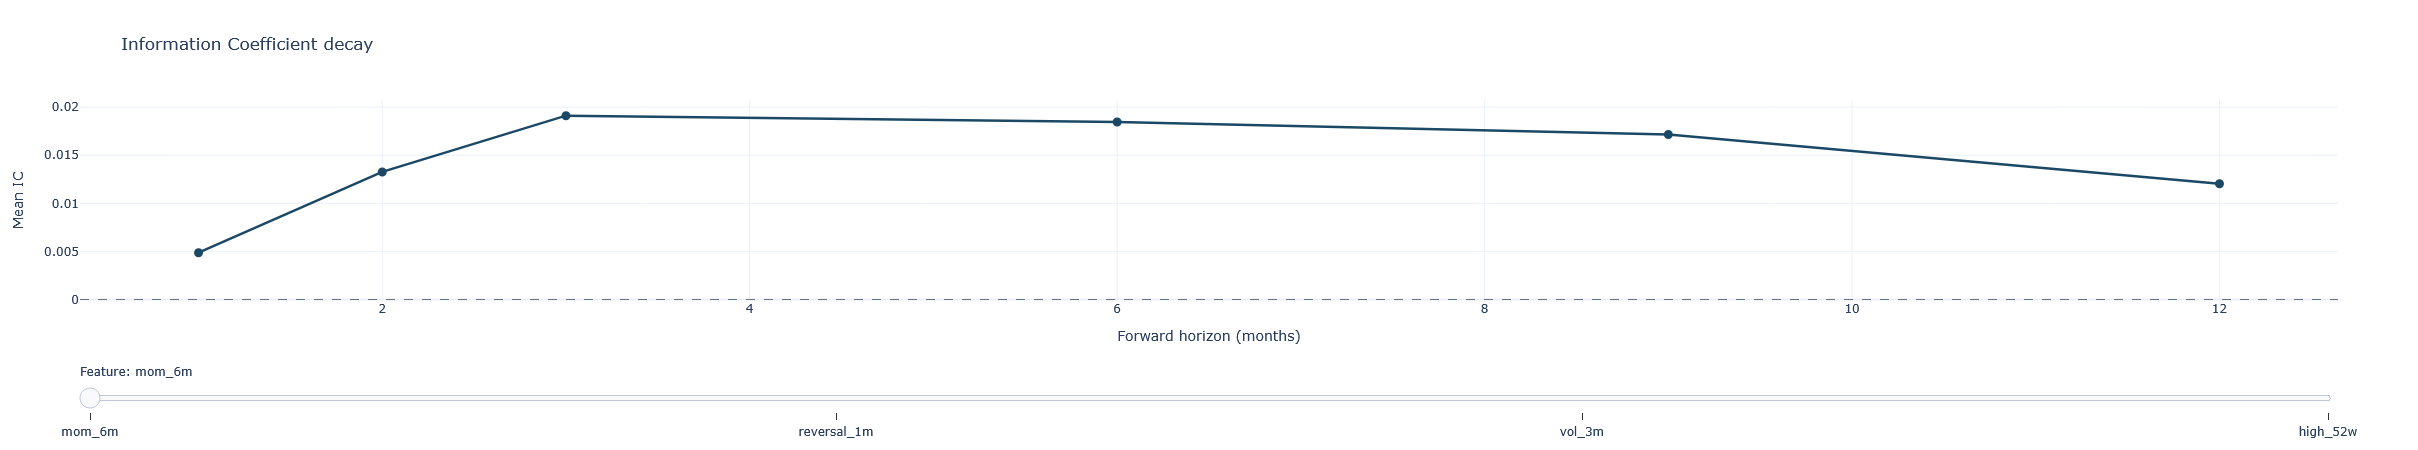

In [54]:
horizons = [1, 2, 3, 6, 9, 12]
decay = {name: [information_coefficient(frame, rets_clean, h).mean() for h in horizons]
         for name, frame in features.items()}

fig = go.Figure()
for i, (name, values) in enumerate(decay.items()):
    fig.add_trace(go.Scatter(x=horizons, y=values, name=name, mode="lines+markers",
                             visible=(i == 0), marker=dict(size=9),
                             line=dict(color=AIRM_COLOURS[i], width=2.5)))

fig.add_hline(y=0, line=dict(color="#64748b", width=1, dash="dash"))
fig.update_layout(
    title="Information Coefficient decay", template=AIRM_TEMPLATE, height=450,
    xaxis_title="Forward horizon (months)", yaxis_title="Mean IC", showlegend=False,
    sliders=[dict(active=0, pad=dict(t=60), currentvalue=dict(prefix="Feature: "),
        steps=[dict(label=name, method="update",
                    args=[{"visible": [j == i for j in range(len(decay))]}])
               for i, name in enumerate(decay)])])
fig.show()

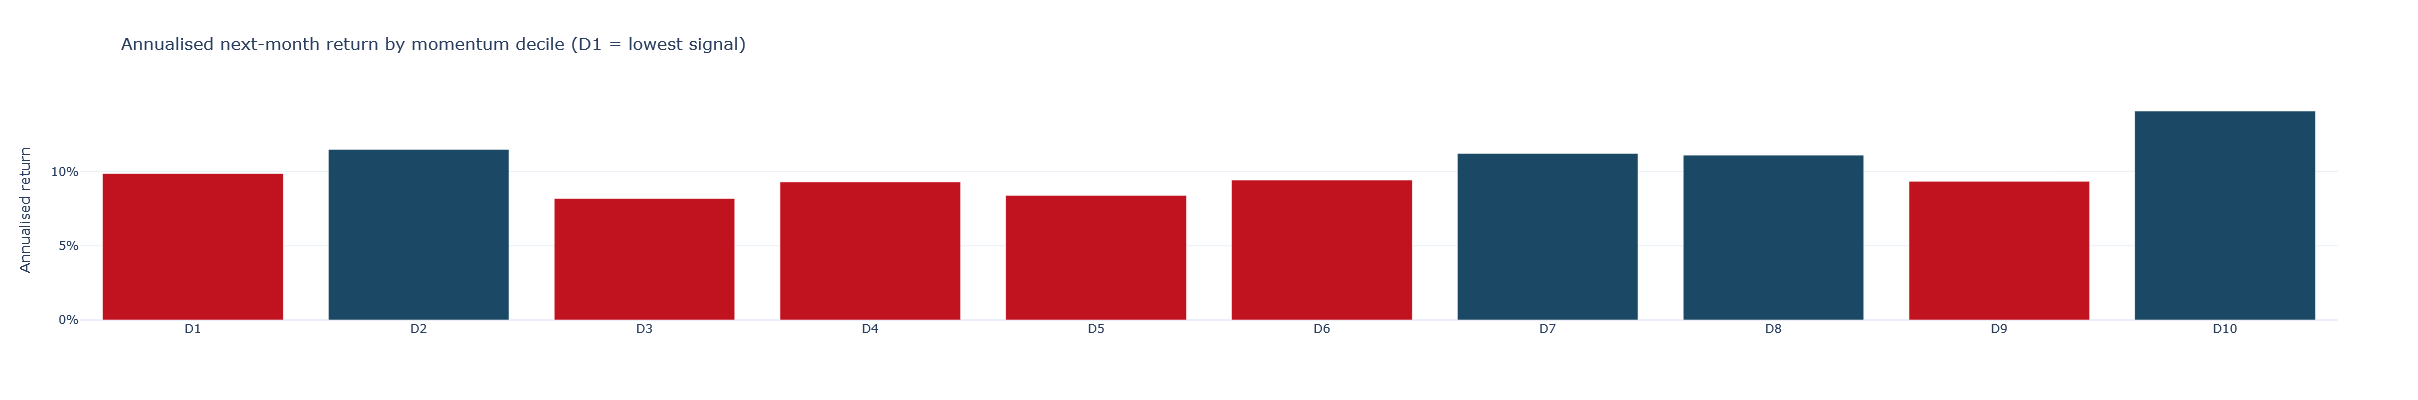

Top decile minus bottom decile: +4.22% a year
Monotonic staircase from D1 to D10? False

A textbook signal rises steadily across the deciles. This one delivers a positive
spread from end to end but wanders in between -- the signature of a weak signal
measured over too short a sample, rather than of no signal at all.


In [55]:
# The same question asked visually: sort stocks into deciles by signal, then look at
# what each decile actually returned next month. A working signal produces a staircase.
def decile_returns(feature, rets, n_bins=10):
    fwd = forward_return(rets, 1)
    out = {b: [] for b in range(n_bins)}
    for t in feature.index:
        if t not in fwd.index:
            continue
        pair = pd.concat([feature.loc[t], fwd.loc[t]], axis=1).dropna()
        if len(pair) < 50:
            continue
        bins = pd.qcut(pair.iloc[:, 0], n_bins, labels=False, duplicates="drop")
        for b, grp in pair.iloc[:, 1].groupby(bins):
            out[b].append(grp.mean())
    return pd.Series({b: np.mean(v) * 12 for b, v in out.items() if v})


dec = decile_returns(features["mom_6m"], rets_clean)
fig = go.Figure(go.Bar(x=[f"D{i+1}" for i in dec.index], y=dec.values,
                       marker=dict(color=["#c1121f" if v < dec.mean() else "#1b4965"
                                          for v in dec.values])))
fig.update_layout(title="Annualised next-month return by momentum decile (D1 = lowest signal)",
                  template=AIRM_TEMPLATE, height=400, showlegend=False,
                  yaxis_title="Annualised return", yaxis_tickformat=".0%")
fig.show()

spread = dec.iloc[-1] - dec.iloc[0]
monotonic = bool((dec.diff().dropna() > 0).all())
print(f"Top decile minus bottom decile: {spread:+.2%} a year")
print(f"Monotonic staircase from D1 to D10? {monotonic}")
print("\nA textbook signal rises steadily across the deciles. This one delivers a positive")
print("spread from end to end but wanders in between -- the signature of a weak signal")
print("measured over too short a sample, rather than of no signal at all.")

---

## 9. What breaks in production

Everything above is still a laboratory exercise. Here is what a practitioner would raise
in a model review that we have not addressed:

**The universe is not stable.** We treated the S&P 500 as fixed. In reality about
20–25 names change every year, and index additions and deletions move prices in themselves.
A production system needs point-in-time membership, not a current snapshot.

**Corporate actions.** Splits, dividends, spin-offs and mergers all break a naive price
series. Our `close` column is not adjusted for dividends, so we have been ignoring roughly
2% a year of return — and ignoring it *unevenly*, since high-dividend sectors are
penalised most. A real study would use total-return prices.

**Prices are not the only data, and the rest is worse.** Fundamental data is restated:
the earnings figure your database shows for Q1 2015 today is not the figure that was
public in April 2015. Using the restated number is look-ahead bias with no visible
`.shift()` missing anywhere. Point-in-time fundamental databases exist precisely because
of this and are expensive precisely because of this.

**Capacity.** Our equal-weighted top-quintile portfolio implicitly buys as much of a
\$2bn company as of Apple. At \$50m of capital that is fine. At \$5bn it is impossible.
Capacity constraints bind long before your Sharpe does.

**Shorting is not free or always possible.** We built a long-only strategy deliberately.
The long-short version requires borrowing stock, which costs money and is least available
for exactly the stocks you most want to short.

**Survivorship in your own research.** The subtlest version of today's lesson: if you test
fifty strategies and present the best one, you have applied survivorship bias to your own
research process. That is Lecture 5.

---

## 10. Exercises

### Core

**C1 — Break it yourself.** In `momentum_signal`, change `skip=1` to `skip=0`. This is not
look-ahead — you are still only using past data — but it changes what the strategy buys.
Re-run the honest backtest. Does performance improve or deteriorate, and what does that
tell you about the one-month reversal effect?

**C2 — How much did the winners matter?** We removed 76 backfilled stocks. Remove instead
a *random* 76 stocks from the universe and re-run. Repeat a few times with different random
seeds. Is the performance drop as large? What does the comparison prove about *why* the
backfilled names mattered?

**C3 — Find the breaking point.** Trading costs are a guess. At what cost, in basis points,
does the strategy stop beating the equal-weighted benchmark? Use `bt_costed` as your
starting point and try a range of values.

**C4 — A fifth feature.** Add a feature to `build_features` that captures whether a stock's
*trading volume* has been unusually high recently (relative to its own past). Compute its
IC. Does volume carry information that price alone does not?

### Stretch

**S1 — Sensitivity of the simulated bias.** In `simulate_universe`, vary `base_hazard` from
0.001 to 0.008 and plot the phantom return against the realised failure rate. Is the
relationship linear? What does the slope tell you about which markets (large cap developed,
small cap, emerging, hedge funds) suffer most from survivorship bias?

**S2 — Is the IC statistically distinguishable from zero?** Our t-statistics assume monthly
ICs are independent. Test that assumption by computing the autocorrelation of the IC series.
If ICs are autocorrelated, are the t-statistics too generous or too conservative? Recompute
with a Newey-West correction and compare.

**S3 — Combine the features.** Build a composite signal by averaging the rank-normalised
versions of all four features, and compute its IC. It should exceed the average of the
individual ICs. Explain why, in terms of the correlation between the features — and derive
the condition under which combining two signals improves the IC.

**S4 — The bias you cannot remove.** Our clean universe still excludes every company that
failed between 2013 and 2018. Using `simulate_universe` to calibrate, estimate a plausible
range for the residual survivorship bias in our real backtest, and restate the final
performance table with that correction applied.

---

## Summary

| | |
|---|---|
| **The claim** | "Better features make better decisions" |
| **The verdict** | Untestable until the data is honest. Data quality dominated model choice by a wide margin. |
| **The number to remember** | Sharpe 4.31 → 0.89, with no change to the strategy |

Three biases, in the order you should check for them:

1. **Look-ahead** — did the signal use information from the period it is predicting?
   *Check by writing out the timeline explicitly.*
2. **Survivorship and backfill** — where did the universe come from, and when was the list
   assembled? *Check by asking what happened to the companies that failed.*
3. **Implementation** — could you actually have traded this, at these prices, at this size?
   *Check by adding delay and costs before you get excited.*

**Next week**, in Lecture 3, we take a dataset we now trust and hand it to an optimiser to
build a portfolio. We will find that the optimisation is the easy part — and that the
estimation problem underneath it fails in a way that has a great deal in common with what
we saw today.